# Date Cleaning & Seasonality Analysis

----------------------------------------------------------------
## Business Case: Okinsurance — Water-Sport Risk Insurance for US Hotels & Resorts
----------------------------------------------------------------

### This notebook focuses on cleaning and analyzing the `Date` column of the GSAF dataset, in order to test **Hypothesis 2**: shark-incident risk varies significantly by month/season.
### The resulting monthly incident counts support a seasonal premium-loading recommendation for the proposed insurance product.
### Country and Activity cleaning are handled in a separate notebook and merged here for the country + month cross-analysis.

# Date Cleaning & Seasonality Pipeline
### 1. Load dataset
### 2. Explore Date column structure
### 3. Extract Month from parsed dates
### 4. Attempt text-based recovery (regex)
### 5. Combine both approaches
### 6. Investigate and correct the January outlier
### 7. Cross-reference with Country (teammate's cleaning)
### 8. Seasonality result — USA

-------------------------------
##### Dataset:
----------------------------------

#### Global Shark Attack File (GSAF) — https://www.sharkattackfile.net/spreadsheets/GSAF5.xls

#### Importing Libraries: Pandas & Regex

##### Note: this notebook reads the dataset from a local file (`GSAF5.xls`, in the same folder) rather than the live URL. The source file on sharkattackfile.net is updated continuously, so reading from the live URL would make the results in this notebook (and in the final presentation) drift over time. Reading from a local, frozen copy keeps the analysis reproducible.

In [1]:
import pandas as pd
import re
import warnings

warnings.filterwarnings("ignore")   # suppresses a harmless pandas date-parsing UserWarning

-------------------------------------------------------------------

## 1. Load Data

In [2]:
df = pd.read_excel("GSAF5.xls", engine="xlrd")

In [3]:
df.head()

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,23rd June,2026.0,Unprovoked,Bahamas,Staniel Cay,Exhuma Cays,Swimming,Unknown,M,12,...,Unknown,Keith Cowley: Kevin McMurray Trackingsharks.co...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,13th June,2026.0,Unprovoked,USA,Florida,Reservation Way near Indian Pass,Swimming,Keira Ralph,F,17,...,Unknown small shark,Keith Cowley: Simon De Marchi: All things Emer...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,13th June,2026.0,Unprovoked,Australia,NSW,Coogee Beach,Swimming,Leah Stewart,F,35,...,Great White Shark 4m,Simon De Marchi: Andrew Currie: ABC NEWS: 9 Ne...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11th June,2026.0,Unprovoked,Galapogos Islands,Santa Fe Island,Mosquera Islet,Snorkeling,Australia Woman,F,?,...,Unknown,Andrew Currie: Facebook: AbsolutCruceros,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8th June,2026.0,Unprovoked,USA,Florida,Panama City,Swimming,Unknown,M,20's,...,2.4m (8ft) Bull shark,James Kingsley:Todd Smith: Kevin McMurray Trac...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.tail()

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
7098,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,Roebuck Bay,Diving,male,M,NaN,...,NaN,"H. Taunton; N. Bartlett, p. 234",ND-0005-RoebuckBay.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,ND.0005,ND.0005,6.0,NaN,NaN
7099,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,NaN,Pearl diving,Ahmun,M,NaN,...,NaN,"H. Taunton; N. Bartlett, pp. 233-234",ND-0004-Ahmun.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,ND.0004,ND.0004,5.0,NaN,NaN
7100,1900-1905,0.0,Unprovoked,USA,North Carolina,Ocracoke Inlet,Swimming,Coast Guard personnel,M,NaN,...,NaN,"F. Schwartz, p.23; C. Creswell, GSAF",ND-0003-Ocracoke_1900-1905.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,ND.0003,ND.0003,4.0,NaN,NaN
7101,1883-1889,0.0,Unprovoked,PANAMA,NaN,"Panama Bay 8ºN, 79ºW",NaN,Jules Patterson,M,NaN,...,NaN,"The Sun, 10/20/1938",ND-0002-JulesPatterson.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,ND.0002,ND.0002,3.0,NaN,NaN
7102,1845-1853,0.0,Unprovoked,CEYLON (SRI LANKA),Eastern Province,"Below the English fort, Trincomalee",Swimming,male,M,15,...,NaN,S.W. Baker,ND-0001-Ceylon.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,ND.0001,ND.0001,2.0,NaN,NaN


## 2. Explore Structure: the `Date` column

In [5]:
df['Date'].dtype

dtype('O')

##### Note: depending on the pandas version/environment, `Date` may already come in parsed as datetime, or may still be plain text — pandas' automatic type inference for this column isn't fully consistent. To keep this notebook reproducible regardless of environment, we explicitly (re)parse it ourselves rather than relying on that automatic guess:

In [6]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7103 entries, 0 to 7102
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            6150 non-null   datetime64[ns]
 1   Year            7101 non-null   float64       
 2   Type            7085 non-null   str           
 3   Country         7053 non-null   str           
 4   State           6616 non-null   str           
 5   Location        6536 non-null   str           
 6   Activity        6520 non-null   str           
 7   Name            6885 non-null   str           
 8   Sex             6525 non-null   str           
 9   Age             4109 non-null   object        
 10  Injury          7067 non-null   str           
 11  Fatal Y/N       6542 non-null   object        
 12  Time            3576 non-null   object        
 13  Species         3972 non-null   str           
 14  Source          7083 non-null   object        
 15  pdf            

##### Finding:
##### Only 6,150 of 7,103 rows (~86.6%) have a valid Date after explicit parsing.

In [8]:
df['Date'].isna().sum()   # 953 missing (~13.4%)

np.int64(953)

In [9]:
# peek at the original raw text behind the missing rows (read separately, since df['Date']
# has already been converted to datetime/NaT above)
df_text_preview = pd.read_excel("GSAF5.xls", engine="xlrd", dtype={'Date': str})
df_text_preview.loc[df['Date'].isna(), 'Date'].head(20)

0      23rd June
1      13th June
2      13th June
3      11th June
4       8th June
5       6th June
6       5th June
7      1st June 
8       1st June
9       31st May
10      30th May
11      25th May
12      24th May
13      22nd May
14      17th May
15      16th May
16    14th April
17     3rd April
18    26th March
19    25th March
Name: Date, dtype: str

##### Finding:
##### The missing rows aren't truly empty in the source file — their original values were free text like "23rd June" (day + month only, no year in the same cell), which pandas couldn't parse automatically.

-------------------------------
## 3. Date Handling — Step 1: Extract Month from parsed dates
-------------------------------

Since `Date` is already parsed for most rows, we can extract `Month` directly, without any extra transformation.

In [10]:
df['Month'] = df['Date'].dt.month

In [11]:
df['Month'].isna().sum()   # 953 rows -> will be excluded from the seasonality analysis

np.int64(953)

In [12]:
df['Month'].isna().mean() * 100   # ~13.4% of rows lack a usable month

np.float64(13.41686611291004)

In [13]:
df.dropna(subset=['Month'])   # demonstrates the null-handling technique
# (a filtered working copy, df_month_clean, is built later in Step 6, after the outlier correction)

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22,Month
20,2022-03-23 00:00:00.000000000,2026.0,Unprovoked,Australia,NSW,Little Avalon Beach,Surfing,Unknown,M,30+,...,Melissa Michaelson: Instagram,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0
78,2025-06-11 00:00:00.000000000,2025.0,Unprovoked,USA,Florida,Boca Grande,Snorkeling,Leah Lendel,F,9,...,Kevin McMurray Trackingsharks.com: James Kings...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0
80,2025-05-29 00:00:00.000000000,2025.0,Unprovoked,USA,North Carolina,Sunset Beach,Swimming,Sean Barton,M,26,...,Kevin McMurray Trackingsharks.com: Clay Crewel...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0
81,2025-05-26 00:00:00.000000000,2025.0,Unprovoked,Vanuatu,South Santo,Espiitu Santo Island,Swimming,Tumas,M,14,...,Kevin McMurray Trackingsharks.com,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0
82,2025-05-15 00:00:00.000000000,2025.0,Unprovoked,Australia,South Australia,Port Noarlunga,Swimming,Richard Vinall,M,66,...,Simon DeMarchi: Todd Smith: 9 News:ABC News,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6952,1721-06-01 00:00:00.000000000,1721.0,Unprovoked,ITALY,Sardinia,"Ponte della Maddelena,",Swimming,male,M,NaN,...,F. Ricciardi; A. De Maddalena.,1721.06.00-Maddalena.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,1721.06.00,1721.06.00,150.0,NaN,NaN,6.0
6953,1703-03-26 00:00:00.000000000,1703.0,Unprovoked,BARBADOS,Southwest coast,Carlisle Bay,Swimming,"Samuel Jennings, a deserter from the British f...",M,19,...,"W.R.Cutter, Vol.1, p.252",1703.03.26-Jennings.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,1703.03.26,1703.03.26,149.0,NaN,NaN,3.0
6958,1691-01-01 00:00:00.000000000,1691.0,Unprovoked,CANADA,Quebec,Gaspé,NaN,Sailor,M,NaN,...,Canadian Shark Attack Registry,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
6964,1970-01-01 00:00:00.000001595,1595.0,Unprovoked,INDIA,Kerala,River Cochin,Ship lay at anchor & man was working on its ru...,male,M,NaN,...,The Voyage of John Huyghen van Linschoten,1595.00.00-Cochin.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,1595.00.00,1595.00.00,140.0,NaN,NaN,1.0


-------------------------------
## 4. Date Handling — Step 2: Attempting text-based recovery (regex)
-------------------------------

For the ~953 rows with a missing `Date`, we suspected the raw text was still present in the source file but had been lost during pandas' automatic type conversion. To test this, we re-read the file forcing `Date` to stay as plain text, then used regex to extract the last word of each string (expected to be the month name, e.g. "June" from "23rd June").

In [14]:
df_dates_fixed = pd.read_excel("GSAF5.xls", engine="xlrd", dtype={'Date': str})

In [15]:
df_dates_fixed['Date'].head(10)

0    23rd June
1    13th June
2    13th June
3    11th June
4     8th June
5     6th June
6     5th June
7    1st June 
8     1st June
9     31st May
Name: Date, dtype: str

In [16]:
df_dates_fixed['Month_name'] = df_dates_fixed['Date'].str.extract(r'([A-Za-z]+)$')
# regex captures only the last word of the string (the month name), ignoring day numbers
# and suffixes like rd/st/th/nd

In [17]:
df_dates_fixed['Month'] = pd.to_datetime(df_dates_fixed['Month_name'], format='%B', errors='coerce').dt.month

In [18]:
df_dates_fixed['Month_name'].value_counts()
# reveals inconsistent formatting: some rows aren't "day + month" text at all

Month_name
s            23
June         12
January      11
July          9
May           8
March         7
August        6
date          6
December      5
November      5
September     4
October       3
R             3
II            3
April         2
February      2
b             2
a             1
Kong          1
Reported      1
weekend       1
Ladysmith     1
D             1
BC            1
Name: count, dtype: int64

In [19]:
df_dates_fixed['Month'].notna().sum()   # only 74 valid months recovered this way

np.int64(74)

##### Finding:
##### This approach alone only recovered 74 valid months across the whole dataset — far fewer than expected — because it ignores the ~86.6% of dates pandas had already parsed correctly on the first read. It also revealed genuinely inconsistent formatting in the source column (e.g. "Kong", "weekend", "Ladysmith" were extracted instead of month names).

-------------------------------
## 5. Date Handling — Step 3: Combined Approach
-------------------------------

We combine both methods: keep the `Month` already extracted from the correctly auto-parsed dates (Step 1), and only apply the regex recovery (Step 2) to the rows that were still missing.

In [20]:
# extracts the month directly from dates that were already parsed correctly
df['Month'] = df['Date'].dt.month

# for the remaining missing rows, recover the month from the raw text version (regex)
df_raw_dates = pd.read_excel("GSAF5.xls", engine="xlrd", dtype={'Date': str})

rows_without_month = df['Month'].isna()   # identifies which rows are still missing a month
month_text = df_raw_dates.loc[rows_without_month, 'Date'].str.extract(r'([A-Za-z]+)$')[0]   # regex recovery
month_recovered = pd.to_datetime(month_text, format='%B', errors='coerce').dt.month   # text -> number (e.g. "May" -> 5)

df.loc[rows_without_month, 'Month'] = month_recovered   # fills in only the rows that were missing

In [21]:
df['Month'].isna().sum()   # missing rows after the combined approach

np.int64(880)

In [22]:
df['Month'].isna().mean() * 100   # ~12.4% missing rate (down from 13.4%)

np.float64(12.389131352949457)

In [23]:
df['Month'].value_counts().sort_index()   # monthly incident counts (before outlier correction)

Month
1.0     816
2.0     391
3.0     430
4.0     454
5.0     426
6.0     507
7.0     706
8.0     608
9.0     547
10.0    462
11.0    423
12.0    453
Name: count, dtype: int64

##### Finding:
##### The combined approach reduced the missing-value rate from 13.4% to ~12.4%.

-------------------------------
## 6. Outlier Investigation — the January Anomaly
-------------------------------

January shows an implausible 816 incidents in the table above — nearly double every neighboring month. This is worth investigating before trusting it.

In [24]:
jan_rows = df['Month'] == 1
(df.loc[jan_rows, 'Date'].dt.day == 1).sum()   # how many January rows fall exactly on day 1

np.int64(338)

##### Finding:
##### 338 of the 816 January rows (41.4%) have the exact date "January 1st" — a signature of incomplete original dates (year only, e.g. "1921"), which Excel/pandas defaults to January 1st when parsing. This is a structural artifact, not a real seasonal spike.

In [25]:
# excludes rows where an incomplete date was defaulted to "January 1st"
january_incomplete_dates = (df['Month'] == 1) & (df['Date'].dt.day == 1)
df_month_clean = df.loc[~january_incomplete_dates].copy()

In [26]:
# final, corrected incident count by month
incidents_by_month = df_month_clean['Month'].value_counts().sort_index()
incidents_by_month

Month
1.0     478
2.0     391
3.0     430
4.0     454
5.0     426
6.0     507
7.0     706
8.0     608
9.0     547
10.0    462
11.0    423
12.0    453
Name: count, dtype: int64

##### Finding:
##### January drops from 816 to a much more realistic 478 once the outlier is removed — in line with neighboring months.

-------------------------------
## 7. Cross-Referencing with Country
-------------------------------

Country cleaning was done separately (see teammate's notebook). We reuse that same cleaning logic here to cross `Month` with `Country`.

In [27]:
# creates a cleaned version of Country (same cleaning logic as the teammate's notebook,
# applied here to cross-reference with Month)
df2 = df.copy()

df2["Country"] = (
    df2["Country"]
    .str.strip()
    .str.title()
    .str.replace(r"\?", "", regex=True)
    .str.replace(r"[^\w\s]", "", regex=True)
)

region_list = ["Africa", "Asia", "Red Sea"]
df2["Country"] = df2["Country"].replace(region_list, "Unknown")
df2["Country"] = df2["Country"].replace(r"^Between.*", "Unknown", regex=True)

In [28]:
df2['Country'].head()

0              Bahamas
1                  Usa
2            Australia
3    Galapogos Islands
4                  Usa
Name: Country, dtype: str

In [29]:
df_month_clean['Country'] = df2['Country']

In [30]:
country_month_summary = (
    df_month_clean
    .groupby(['Country', 'Month'])
    .size()
    .reset_index(name='Incidents')
)
country_month_summary.head(20)

,Country,Month,Incidents
0,Admiralty Islands,10.0,1
1,American Samoa,8.0,1
2,American Samoa,12.0,2
3,Andaman Nicobar Islandas,9.0,1
4,Argentina,1.0,1
5,Argentina,2.0,1
6,Aruba,12.0,1
7,Atlantic Ocean,1.0,2
8,Atlantic Ocean,2.0,1
9,Atlantic Ocean,7.0,2


-------------------------------
## 8. Seasonality Result — USA
-------------------------------

Since the proposed insurance product targets US hotels & resorts, we narrow the analysis to the USA specifically.

In [31]:
usa_summary = country_month_summary[country_month_summary['Country'] == 'Usa']
usa_summary.sort_values('Month')

,Country,Month,Incidents
621,Usa,1.0,53
622,Usa,2.0,65
623,Usa,3.0,113
624,Usa,4.0,173
625,Usa,5.0,181
626,Usa,6.0,273
627,Usa,7.0,409
628,Usa,8.0,345
629,Usa,9.0,313
630,Usa,10.0,227


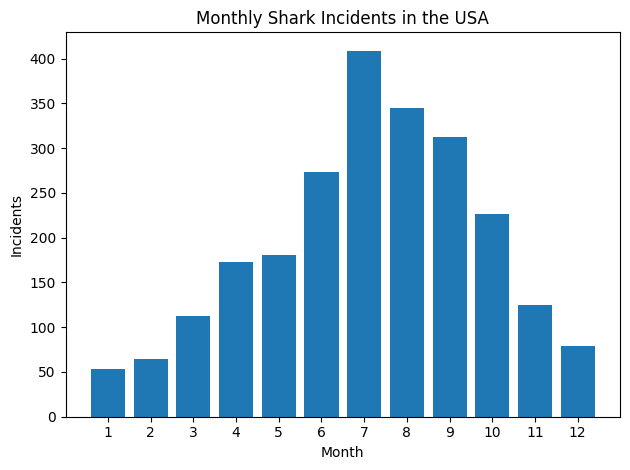

In [32]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(usa_summary['Month'], usa_summary['Incidents'])
plt.title("Monthly Shark Incidents in the USA")
plt.xlabel("Month")
plt.ylabel("Incidents")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

##### Note: incidents peak sharply in July, nearly double the surrounding months — directly supporting a seasonal premium adjustment for peak summer months (Hypothesis 2 supported).